# Predictive Model Generation with Random Forest: Crocodile Dataset Practice
### Random Forest Classifier
---

**Author** Iván Jarpa Manríquez | Senior Data Analyst & AI Agent Developer |
**Date** September 2026 |
**Objective** Build and evaluate a Random Forest Classifier to predict the conservation status in the crocodile dataset. |
**Dataset** Crocodile Dataset (`crocodile_dataset.csv`)

---

## Table of Contents
1. [Enviroment Setup & Data Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Data Preprocessing](#3)
4. [Model Training (Random Forest)](#4)
5. [Model Evaluation](#5)
5. [Feature Importance & Conclusions](#6)

---

## 1. Enviroment Setup & Data Loading
In this section, we import all required libraries for data manipulation, visualization, modeling, and evaluation. We also load the dataset into memory.

In [17]:
# Data manipulation and numerical operations
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Scikit-Learn modules
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# load the dataset
crocoset = pd.read_csv("/kaggle/input/datasets/zadafiyabhrami/global-crocodile-species-dataset/crocodile_dataset.csv", index_col=0)

# Quick preview
crocoset.head()

,Common Name,Scientific Name,Family,Genus,Observed Length (m),Observed Weight (kg),Age Class,Sex,Date of Observation,Country/Region,Habitat Type,Conservation Status,Observer Name,Notes
Observation ID,,,,,,,,,,,,,,
1,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,1.90,62.0,Adult,Male,31-03-2018,Belize,Swamps,Least Concern,Allison Hill,Cause bill scientist nation opportunity.
2,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,4.09,334.5,Adult,Male,28-01-2015,Venezuela,Mangroves,Vulnerable,Brandon Hall,Ago current practice nation determine operatio...
3,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,1.08,118.2,Juvenile,Unknown,07-12-2010,Venezuela,Flooded Savannas,Critically Endangered,Melissa Peterson,Democratic shake bill here grow gas enough ana...
4,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,2.42,90.4,Adult,Male,01-11-2019,Mexico,Rivers,Least Concern,Edward Fuller,Officer relate animal direction eye bag do.
5,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,3.75,269.4,Adult,Unknown,15-07-2019,India,Rivers,Vulnerable,Donald Reid,Class great prove reduce raise author play mov...


## 2. Exploratory Data Analysis (EDA)
In this section, we inspect the dataset structure, statistical summaries, missing values, and the target variable distribution (`conservation_status`).

### Dataset Dimensions & Data Types
Checking the shape of the dataset and inspecting the data type of each feature.

In [18]:
crocoset.shape

(1000, 14)

In [19]:
crocoset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1 to 1000
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Common Name           1000 non-null   object 
 1   Scientific Name       1000 non-null   object 
 2   Family                1000 non-null   object 
 3   Genus                 1000 non-null   object 
 4   Observed Length (m)   1000 non-null   float64
 5   Observed Weight (kg)  1000 non-null   float64
 6   Age Class             1000 non-null   object 
 7   Sex                   1000 non-null   object 
 8   Date of Observation   1000 non-null   object 
 9   Country/Region        1000 non-null   object 
 10  Habitat Type          1000 non-null   object 
 11  Conservation Status   1000 non-null   object 
 12  Observer Name         1000 non-null   object 
 13  Notes                 1000 non-null   object 
dtypes: float64(2), object(12)
memory usage: 117.2+ KB


### Missing Values Inspection
Verifying if there are any null or missing values across features.

>**Note:** Checking for missing values is performed here primarily for educational and validation purposes, as the dataset does not contain missin or null data.

In [20]:
crocoset.isnull().sum()

Common Name             0
Scientific Name         0
Family                  0
Genus                   0
Observed Length (m)     0
Observed Weight (kg)    0
Age Class               0
Sex                     0
Date of Observation     0
Country/Region          0
Habitat Type            0
Conservation Status     0
Observer Name           0
Notes                   0
dtype: int64

### Summary Statistics
Computing descriptive statistic for numerical variables (mean, standar deviation, min, max).

In [21]:
crocoset.describe()

,Observed Length (m),Observed Weight (kg)
count,1000.000000,1000.000000
mean,2.415110,155.771900
std,1.097542,175.186788
min,0.140000,4.400000
25%,1.637500,53.225000
50%,2.430000,100.600000
75%,3.010000,168.875000
max,6.120000,1139.700000


### Target Variable Distribution and Visualization (`conservation status`)
Analyzing class balance to identify potential class imbalancing in the dataset.

In [22]:
crocoset["Conservation Status"].value_counts()

Conservation Status
Least Concern            384
Critically Endangered    275
Vulnerable               170
Data Deficient           115
Endangered                56
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

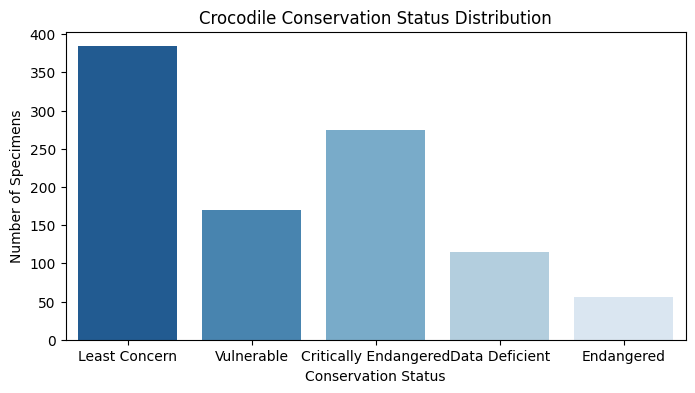

In [23]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=crocoset, 
    x="Conservation Status", 
    hue="Conservation Status", 
    palette="Blues_r", 
    legend=False)

plt.title("Crocodile Conservation Status Distribution")
plt.xlabel("Conservation Status")
plt.ylabel("Number of Specimens")
plt.show

> **Interpretation:** The target variable shows significant class imbalance, with `Least Concern` dominating the dataset (384 specimens) while `Endangered` represent a minority class (56 specimens). To mitigate bias during training, we will user stratified splitting and class weight balancing.

## 3. Data Preprocessing and Feature Engineering
In this section, we prepare the dataset for model training. This includes separating features from the target variable, performing a stratified train-test split, and encoding categorical variables into numerical format **after** the split to prevent data leakage.

### Feature Matrix ($x$) and Target Vector ($y$) Separation
Isolating the predictor features from the categorical target variable (`Conservation Status`).
To ensure optimal model generalization and prevent overfitting, we prune columns based on cardinality extremes:
* **High-Cardinality/Text Features:** Dropped unique identifiers, names, dates, and free-form notes (e.g., `Common Name`, `Scientific Name`, `Observer Name`, `Date of Observation`, `Notes`) to avoid target leakage and memory inflation.
* **Proxy Features:** Dropped `Country/Region` and `Habitat Type`. In this dataset, `Conservation Status` is a fixed attribute of the species (not the individual), and both geographic variables turned out to be near 1:1 proxies for species identity — keeping them let the model shortcut the biological signal entirely, inflating accuracy without learning anything meaningful.
* **Predictive Set:** Retained key biological measurements (`Observed Length`, `Observed Weight`) and demographics (`Age Class`, `Sex`).

In [ ]:
x = crocoset.drop(columns=[
    "Conservation Status",
    "Common Name",
    "Scientific Name",
    "Family",
    "Genus",
    "Date of Observation",
    "Observer Name",
    "Notes",
    "Country/Region",
    "Habitat Type"
    ])

y = crocoset["Conservation Status"]

### Stratified Train-Test Split
Splitting the dataset into 80% training and 20% testing sets. We apply `stratify=y` to preserve the imbalanced class proportions across both sets.

> **Order note:** The split is performed **before** categorical encoding. Fitting `pd.get_dummies` on the full dataset first would let the test set influence the feature space seen during training (i.e. the model would train being aware of the complete universe of categories, some coming only from the held-out test set) — a subtle form of data leakage.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=777, stratify=y
)

### Categorical Feature Encoding
Applying one-hot encoding (`pd.get_dummies`) to ensure all predictor features are strictly numerical for Scikit-Learn algorithms. Encoding is fitted separately on `x_train` and `x_test` so no information from the test set leaks into the training feature space.

> **Column alignment:** since `x_train` and `x_test` are encoded independently, a category present in only one of the two sets would otherwise produce mismatched dummy columns. We reindex `x_test` against `x_train`'s columns (filling missing ones with `0`) so both sets share the exact same feature space the model was fit on.

In [ ]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

## 4. Model Training (Random Forest)
In this section, we instantiate and train the Random Forest Classifier using the preprocesed training dataset (`x_train`,`y_train`).

### Model Instantiation & Hyperparameter Setup
Configuring the `RandomForestClassifier` with `class_weight='balanced'` to handle class imbalance and setting `random_state=777`for exact reproducibility.

In [27]:
rf_model = RandomForestClassifier(class_weight="balanced", random_state=777)

### Model Fitting
Training the algorithm on the training dataset

In [28]:
rf_model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=777)

## 5. Model Evaluation
In this section, we evaluate the trained Random Forest model on the unseen test set (`x_test`). We assess overall accuracy, detailed class metrics via a clasification report, and a confusion matrix visualization.

### Model Predictions
Generating predictions for the test datasets.

In [29]:
y_pred = rf_model.predict(x_test)

### Clasification Metrics
Computing precision, recall, F1-score, and support  for each conservation status class.

In [30]:
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.9850

                       precision    recall  f1-score   support

Critically Endangered       1.00      1.00      1.00        55
       Data Deficient       1.00      1.00      1.00        23
           Endangered       1.00      1.00      1.00        11
        Least Concern       0.97      0.99      0.98        77
           Vulnerable       0.97      0.94      0.96        34

             accuracy                           0.98       200
            macro avg       0.99      0.99      0.99       200
         weighted avg       0.98      0.98      0.98       200



### Confusion Matrix Visualization
Visualizing true versus predicted classifications to identify specific misclassifications across target classes.

<Figure size 800x600 with 0 Axes>

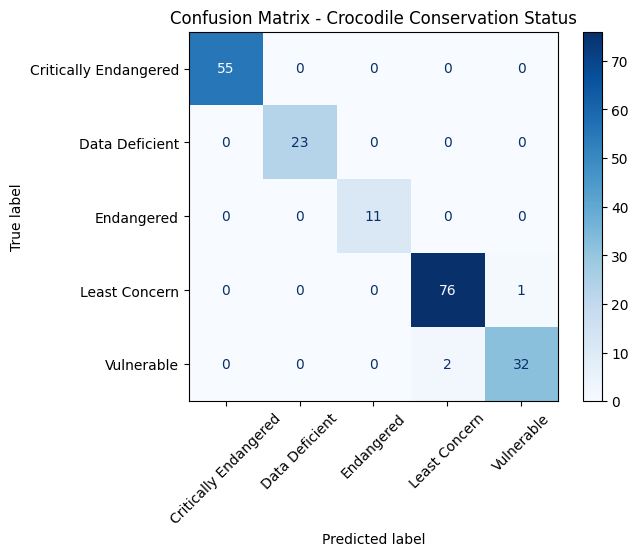

In [31]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Blues", xticks_rotation=45
)
plt.title("Confusion Matrix - Crocodile Conservation Status")
plt.show()

### Feature Importance Analysis & Leakage Verification
Evaluating the Gini importance of individual features to ensure balanced decision-making across predictors and verify the absence of target leakage after removing high-cardinality and proxy variables.

In [ ]:
feature_importances = pd.Series(
    rf_model.feature_importances_, index=x_train.columns
).sort_values(ascending=False)
print(feature_importances)

> **Verification Note:** After removing taxonomic identifiers and the geographic proxy variables (`Country/Region`, `Habitat Type`), feature importance is distributed strictly across the remaining biological and demographic parameters (`Observed Length`, `Observed Weight`, `Age Class`, `Sex`). This gives a more honest — and notably lower — measure of how well individual-level measurements actually predict species-level conservation status.